# GARCH(1,1) Market Risk Model — ETERNAL.NS (Zomato)
### Dynamic Volatility, Value at Risk & Expected Shortfall
**Stock:** ETERNAL.NS | **Period:** July 2021 – May 2026 | **Model:** GARCH(1,1)

This notebook builds a dynamic market risk model from scratch using GARCH(1,1) conditional volatility estimation, 
99% Value at Risk forecasting, backtesting, and Expected Shortfall. 
Replicating the core framework used by risk desks under Basel III.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
from arch import arch_model

## 1. Data & Log Returns
Daily adjusted closing prices for ETERNAL.NS are sourced via yfinance from Zomato's NSE listing date. 
Log returns are computed as ln(Pt/Pt-1). The return series exhibits clear **volatility clustering** — 
large moves tend to follow large moves, and calm periods cluster together. This violates the constant 
variance assumption of simple models and motivates the use of GARCH.
    

In [5]:
data = yf.download(tickers = "ETERNAL.NS", start = "2021-7-23", 
            auto_adjust = True)
price = data["Close"].dropna()

[*********************100%***********************]  1 of 1 completed


In [6]:
price.tail()

Ticker,ETERNAL.NS
Date,
2026-05-13,237.820007
2026-05-14,245.820007
2026-05-15,241.179993
2026-05-18,241.399994
2026-05-19,247.210007


In [7]:
log_returns = np.log(price/ price.shift(1)).dropna().squeeze()
log_returns.describe()

count    1168.000000
mean        0.000577
std         0.030390
min        -0.218425
25%        -0.015133
50%         0.000000
75%         0.016744
max         0.182142
Name: ETERNAL.NS, dtype: float64

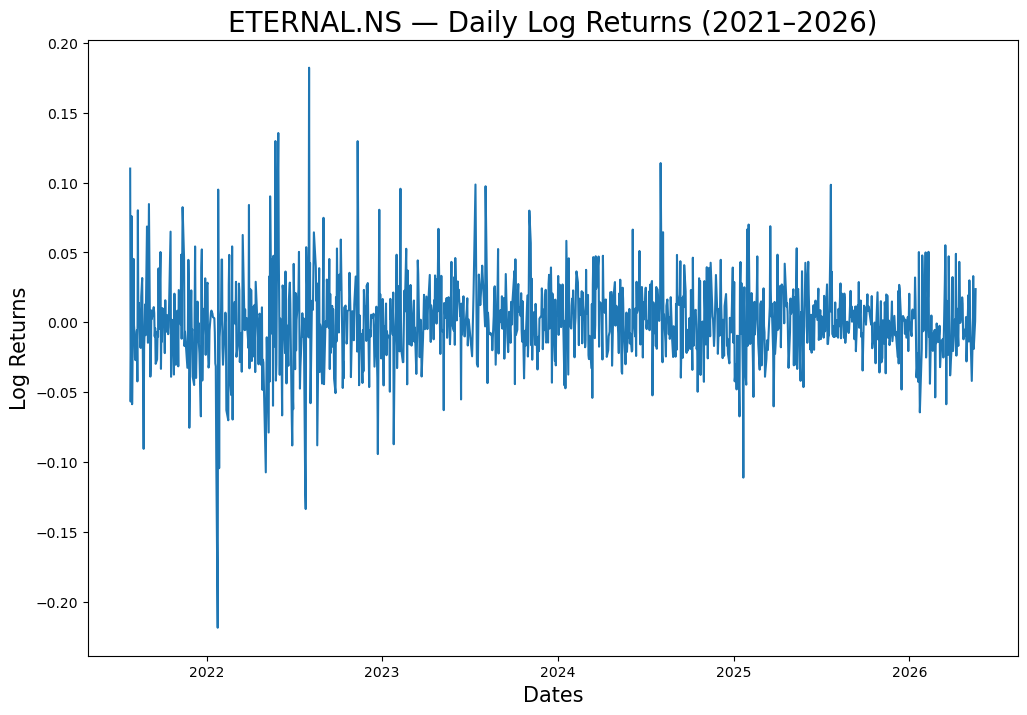

In [8]:
plt.figure(figsize = (12,8))
plt.plot(log_returns)
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Log Returns", fontsize = 15)
plt.title("ETERNAL.NS — Daily Log Returns (2021–2026)", fontsize = 20)
plt.show()

## 2. GARCH(1,1) Estimation
The GARCH(1,1) model estimates conditional variance as:

    σ²t = ω + α·ε²t-1 + β·σ²t-1

- **ω = 0.0000923** — variance intercept; implies long run daily volatility of ~3.02%
- **α = 0.0999** — shock sensitivity; large moves yesterday increase today's variance by ~10%
- **β = 0.7989** — persistence; 80% of yesterday's variance carries into today
- **α + β = 0.8988** — below 1, confirming the process is stationary and volatility mean-reverts

In [9]:
model = arch_model(log_returns, p = 1, q = 1, vol = "Garch")
result = model.fit(disp = "off")

C:\Users\sayee\anaconda3\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0009228. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [10]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:             ETERNAL.NS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                2488.77
Distribution:                  Normal   AIC:                          -4969.55
Method:            Maximum Likelihood   BIC:                          -4949.29
                                        No. Observations:                 1168
Date:                Wed, May 20 2026   Df Residuals:                     1167
Time:                        04:28:27   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.3023e-03  7.606e-04      1.712  8.686e-02 [-1.885e-04,2.793e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      9.2271e-05  4.955e-05      1.862  6.256e-02 [-4.837e-06,1.894e-04]
alpha[1]       0.1000  4.807e-02      2.080  3.750e-02    [5.781e-03,  0.194]
beta[1]        0.7999  8.577e-02      9.326  1.099e-20      [  0.632,  0.968]
=============================================================================

Covariance estimator: robust
"""

In [11]:
cond_vol = result.conditional_volatility.squeeze()
cond_vol

Date
2021-07-26    0.045575
2021-07-27    0.054175
2021-07-28    0.052688
2021-07-29    0.048300
2021-07-30    0.050152
                ...   
2026-05-13    0.027605
2026-05-14    0.026693
2026-05-15    0.027626
2026-05-18    0.027280
2026-05-19    0.026221
Name: cond_vol, Length: 1168, dtype: float64

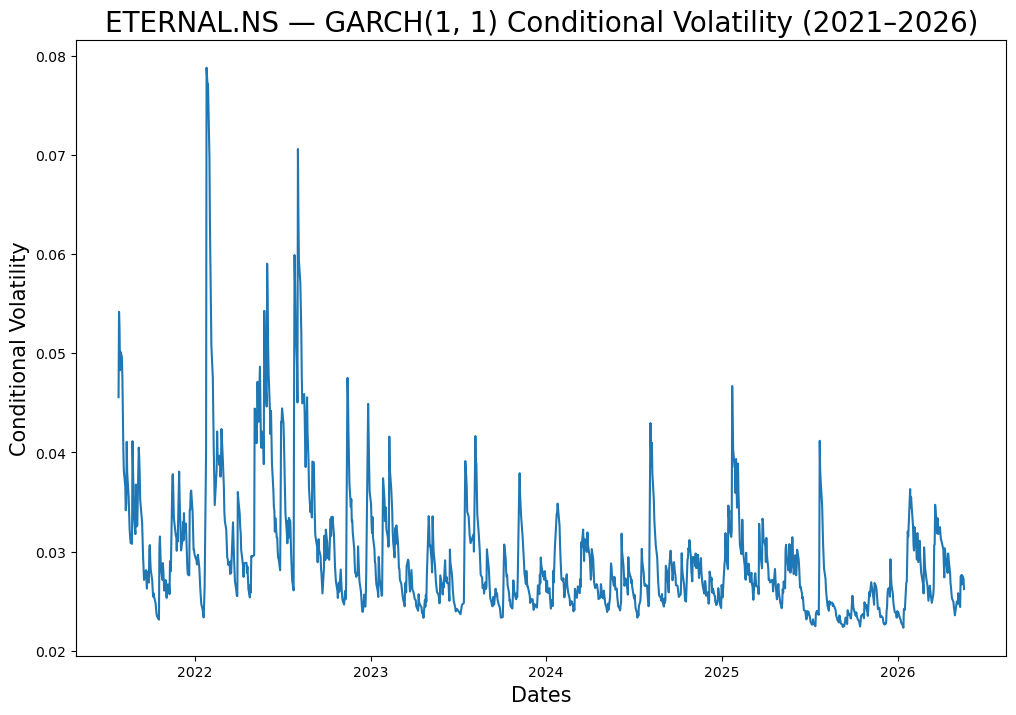

In [12]:
plt.figure(figsize = (12,8))
plt.plot(cond_vol)
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Conditional Volatility", fontsize = 15)
plt.title("ETERNAL.NS — GARCH(1, 1) Conditional Volatility (2021–2026)", fontsize = 20)
plt.show()

## 3. Value at Risk (99%)
1-day 99% VaR is computed as:

    VaR = μ - z·σt  ,  where z = 2.326 (99th percentile)

Unlike static VaR models, GARCH-based VaR updates daily with the conditional volatility estimate, widening during stress periods and tightening during calm regimes. **Backtesting result: 14 breaches out of 1,165 days (1.20%)**.

In [13]:
z = stats.norm.ppf(0.99)
z

np.float64(2.3263478740408408)

In [ ]:
mean = log_returns.mean()

In [ ]:
VaR_99 = mean - z * cond_vol
VaR_99

In [ ]:
breaches = log_returns < VaR_99
breaches

In [ ]:
breach_days = log_returns[breaches]
breach_days

In [ ]:
len(breach_days)

In [ ]:
len(breach_days) / len(log_returns) * 100

In [ ]:
plt.figure(figsize = (16,8))
plt.plot(log_returns)
plt.plot(VaR_99, color = "red")
plt.scatter(breach_days.index, breach_days.values, color = "Black")
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Daily Log Returns / VaR", fontsize = 15)
plt.title("ETERNAL.NS — GARCH(1,1) VaR (99%) vs Actual Returns", fontsize = 20)
plt.show()

## 4. Expected Shortfall (99%)
**ES = -10.18%**

Expected Shortfall answers what VaR cannot, given that we have already breached VaR, what is the average loss on those worst days? ES is the mean of all 14 breach day returns. The gap between VaR (~6% in calm periods) and ES (-10.18%) highlights the fat-tailed nature of Zomato's return distribution.

In [ ]:
ES_99 = breach_days.mean()
ES_99

In [ ]:
plt.figure(figsize = (16,8))
plt.plot(log_returns, label = "Log Returns")
plt.plot(VaR_99, color = "red", label = "VaR at 99% CL")
plt.scatter(breach_days.index, breach_days.values, color = "Black", label = "Breach Days")
plt.axhline(ES_99, color = "Green", linestyle = "--", label = "ES at 99% CL")
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Daily Log Returns / VaR / ES", fontsize = 15)
plt.title("ETERNAL.NS — GARCH(1,1) VaR (99%) vs Actual Returns", fontsize = 20, fontweight='bold')
plt.legend(loc = "best", fontsize = 12)
plt.show()

#### **Prepared by:** Yusuf Sayeed | FRM Part 1 Cleared | FMVA